In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/ML_Y_DL/archive.zip" "/content/archive.zip"


In [7]:
import zipfile

with zipfile.ZipFile("/content/archive.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/archive")


In [ ]:
!find /content/archive -maxdepth 4 -type d


/content/archive
/content/archive/archive
/content/archive/archive/Banana
/content/archive/archive/Mango
/content/archive/archive/Pomegranate
/content/archive/archive/Peach
/content/archive/archive/Pear
/content/archive/archive/Apple
/content/archive/archive/Apple/Apple B
/content/archive/archive/Apple/Total Number of Apples
/content/archive/archive/Apple/Apple F
/content/archive/archive/Apple/Apple C
/content/archive/archive/Apple/Apple E
/content/archive/archive/Apple/Apple D
/content/archive/archive/Apple/Apple A
/content/archive/archive/Guava
/content/archive/archive/Guava/guava total final
/content/archive/archive/Guava/guava A
/content/archive/archive/Guava/guava B
/content/archive/archive/Guava/Guava total
/content/archive/archive/Pitaya
/content/archive/archive/Tomatoes
/content/archive/archive/Carambola
/content/archive/archive/Plum
/content/archive/archive/Orange
/content/archive/archive/Kiwi
/content/archive/archive/Kiwi/Kiwi C
/content/archive/archive/Kiwi/kiwi A
/content/a

In [8]:
import glob

all_paths = glob.glob("/content/archive/**/*.jpg", recursive=True)
all_paths += glob.glob("/content/archive/**/*.png", recursive=True)
all_paths += glob.glob("/content/archive/**/*.jpeg", recursive=True)

print("Total imágenes:", len(all_paths))
print(all_paths[:10])


Total imágenes: 70549
['/content/archive/archive/Guava/Guava total/GuavaÒÇé1197 resized.jpg', '/content/archive/archive/Guava/Guava total/GuavaÒÇé2377 resized.jpg', '/content/archive/archive/Guava/Guava total/GuavaÒÇé2119 resized.jpg', '/content/archive/archive/Guava/Guava total/GuavaÒÇé2220 resized.jpg', '/content/archive/archive/Guava/Guava total/GuavaÒÇé815 resized.jpg', '/content/archive/archive/Guava/Guava total/1GuavaÒÇé2635 resized.jpg', '/content/archive/archive/Guava/Guava total/GuavaÒÇé1338 resized.jpg', '/content/archive/archive/Guava/Guava total/GuavaÒÇé690 resized.jpg', '/content/archive/archive/Guava/Guava total/GuavaÒÇé480 resized.jpg', '/content/archive/archive/Guava/Guava total/GuavaÒÇé2407 resized.jpg']


In [9]:
import os

classes = sorted({p.split("/")[-2] for p in all_paths})
print(classes)


['Apple A', 'Apple B', 'Apple C', 'Apple D', 'Apple E', 'Apple F', 'Banana', 'Carambola', 'Guava total', 'Kiwi B', 'Kiwi C', 'Mango', 'Orange', 'Peach', 'Pear', 'Persimmon', 'Pitaya', 'Plum', 'Pomegranate', 'Tomatoes', 'Total Number of Apples', 'Total Number of Kiwi fruit', 'guava A', 'guava B', 'guava total final', 'kiwi A', 'muskmelon']


In [10]:
labels = [classes.index(p.split("/")[-2]) for p in all_paths]


### EFFICENT NET - MODELO

In [11]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def load_and_preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

ds = tf.data.Dataset.from_tensor_slices((all_paths, labels))
ds = ds.map(load_and_preprocess).shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

base.trainable = False

model = tf.keras.Sequential([
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(classes), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(ds, epochs=20)


Epoch 1/20
2205/2205 ━━━━━━━━━━━━━━━━━━━━ 2976s 1s/step - accuracy: 0.9106 - loss: 0.3011
Epoch 2/20
2205/2205 ━━━━━━━━━━━━━━━━━━━━ 2736s 1s/step - accuracy: 0.9336 - loss: 0.1896
Epoch 3/20
1696/2205 ━━━━━━━━━━━━━━━━━━━━ 10:35 1s/step - accuracy: 0.9694 - loss: 0.0933

In [ ]:
!ls /content/drive/MyDrive/ML_Y_DL


 archive			 kiwi-pruebas.jpg
 archive.zip			 Ml-pipeline-image-vector.ipynb
 bananas-prueba.jpg		 Random_Forest_Alejandro.ipynb
 Efficente_Net_Alejandro.ipynb	 random_forest_model.pkl
 efficientnet_final.h5		 test_dataset.csv
'Kiwi A002-prueba dataset.png'	 train_dataset.csv


In [ ]:
model.save("/content/drive/MyDrive/ML_Y_DL/efficientnet_final.h5")


In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model("/content/drive/MyDrive/ML_Y_DL/efficientnet_final.h5")


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/ML_Y_DL/efficientnet_final.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### EFFICENT NET - MÉTRICAS MODELO

In [12]:
import os
import shutil
import random

base_dir = "/content/archive/archive"
train_dir = "/content/archive/train"
test_dir = "/content/archive/test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Recorrer cada fruta (clase)
for class_name in os.listdir(base_dir):
    class_path = os.path.join(base_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Crear carpetas de clase en train y test
    os.makedirs(os.path.join(train_dir, class_name), exist_ok=True)
    os.makedirs(os.path.join(test_dir, class_name), exist_ok=True)

    # Recoger imágenes de TODAS las subcarpetas internas
    image_list = []
    for root, dirs, files in os.walk(class_path):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                image_list.append(os.path.join(root, f))

    if len(image_list) == 0:
        continue

    random.shuffle(image_list)
    split = int(len(image_list) * 0.8)

    train_images = image_list[:split]
    test_images = image_list[split:]

    # Mover imágenes
    for img_path in train_images:
        shutil.copy(img_path, os.path.join(train_dir, class_name))

    for img_path in test_images:
        shutil.copy(img_path, os.path.join(test_dir, class_name))

print("✔ Dataset creado correctamente en train/ y test/")




✔ Dataset creado correctamente en train/ y test/


In [15]:
!cp -r /content/archive/train "/content/drive/MyDrive/ML_Y_DL/dataset_fruit/train"
!cp -r /content/archive/test "/content/drive/MyDrive/ML_Y_DL/dataset_fruit/test"


In [18]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/ML_Y_DL/dataset_fruit/train/train",
    image_size=(224, 224),
    batch_size=64
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/ML_Y_DL/dataset_fruit/test/test",
    image_size=(224, 224),
    batch_size=64
)


Found 56208 files belonging to 15 classes.
Found 14094 files belonging to 15 classes.


In [20]:
model = load_model("/content/drive/MyDrive/ML_Y_DL/efficientnet_final.h5")



In [21]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [22]:
history = model.fit(train_ds, validation_data=test_ds, epochs=5)


Epoch 1/5
879/879 ━━━━━━━━━━━━━━━━━━━━ 652s 702ms/step - accuracy: 0.8521 - loss: 0.7699 - val_accuracy: 0.9811 - val_loss: 0.0840
Epoch 2/5
879/879 ━━━━━━━━━━━━━━━━━━━━ 665s 710ms/step - accuracy: 0.9848 - loss: 0.0700 - val_accuracy: 0.9923 - val_loss: 0.0391
Epoch 3/5
879/879 ━━━━━━━━━━━━━━━━━━━━ 621s 707ms/step - accuracy: 0.9919 - loss: 0.0398 - val_accuracy: 0.9962 - val_loss: 0.0234
Epoch 4/5
879/879 ━━━━━━━━━━━━━━━━━━━━ 594s 676ms/step - accuracy: 0.9949 - loss: 0.0267 - val_accuracy: 0.9980 - val_loss: 0.0168
Epoch 5/5
879/879 ━━━━━━━━━━━━━━━━━━━━ 595s 677ms/step - accuracy: 0.9966 - loss: 0.0196 - val_accuracy: 0.9984 - val_loss: 0.0119


In [23]:
model.save("/content/drive/MyDrive/ML_Y_DL/efficientnet_final.h5")


In [24]:
import numpy as np

y_true = []
y_pred = []

for batch_images, batch_labels in test_ds:
    preds = model.predict(batch_images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(batch_labels.numpy())
    y_pred.extend(preds)


2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 95ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/st

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision (macro):", precision_score(y_true, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_true, y_pred, average='macro'))
print("F1-macro:", f1_score(y_true, y_pred, average='macro'))


Accuracy: 0.998368099900667
Precision (macro): 0.9984247185815868
Recall (macro): 0.9980330856134357
F1-macro: 0.9982279490215167


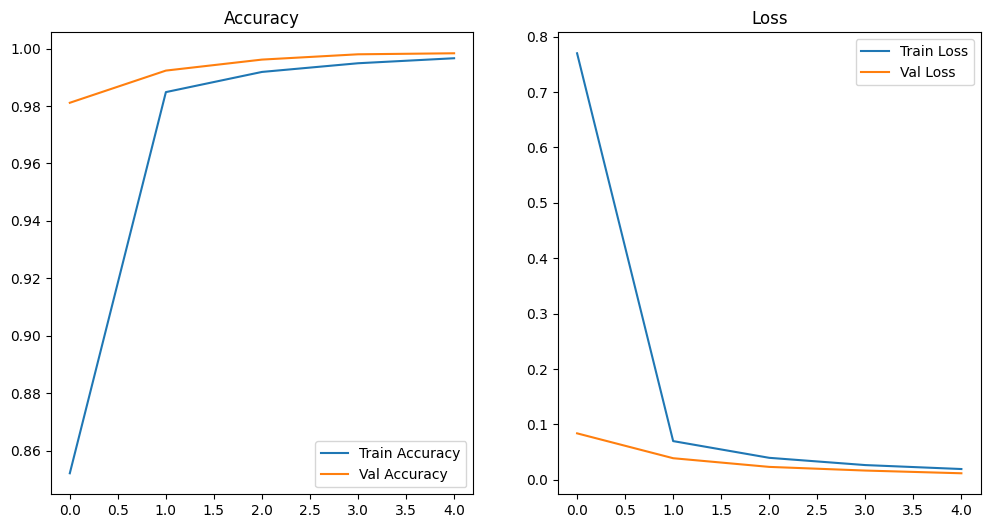

In [26]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy')
plt.plot(epochs_range, val_acc, label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()


El gráfico muestra cómo evoluciona el aprendizaje del modelo.

“Train” = datos que usa para aprender.

“Val” = datos que NO ha visto (validación).

Si ambas curvas suben y bajan juntas → modelo sano.

Si val_accuracy es alta → generaliza bien.

Si val_loss baja → no hay sobreajuste.

Gráfico es bastante sólido. El modelo está funcionando de maravilla.

# EFFICENT NET - PREDICCIONES

In [ ]:
import cv2
import numpy as np

img = cv2.imread("/content/drive/MyDrive/ML_Y_DL/bananas-prueba.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

x = np.expand_dims(img, axis=0)
x = tf.keras.applications.efficientnet.preprocess_input(x)


In [ ]:
import cv2
import numpy as np
import tensorflow as tf

# cargar modelo
model = tf.keras.models.load_model("/content/drive/MyDrive/ML_Y_DL/efficientnet_final.h5")

# cargar imagen desde tu carpeta ML_Y_DL
img = cv2.imread("/content/drive/MyDrive/ML_Y_DL/bananas-prueba.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (224, 224))

# preparar para EfficientNet
x = np.expand_dims(img, axis=0)
x = tf.keras.applications.efficientnet.preprocess_input(x)

# predecir
pred = model.predict(x)
pred_class = np.argmax(pred)

print("Predicción:", pred_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Predicción: 6


In [ ]:
print("Predicción:", classes[pred_class])


Predicción: Banana


In [ ]:
for c, p in zip(classes, pred[0]):
    print(f"{c}: {p:.4f}")


Apple A: 0.0000
Apple B: 0.0000
Apple C: 0.0000
Apple D: 0.0000
Apple E: 0.0000
Apple F: 0.0000
Banana: 0.9998
Carambola: 0.0001
Guava total: 0.0000
Kiwi B: 0.0000
Kiwi C: 0.0000
Mango: 0.0001
Orange: 0.0000
Peach: 0.0000
Pear: 0.0000
Persimmon: 0.0000
Pitaya: 0.0000
Plum: 0.0000
Pomegranate: 0.0000
Tomatoes: 0.0000
Total Number of Apples: 0.0000
Total Number of Kiwi fruit: 0.0000
guava A: 0.0000
guava B: 0.0000
guava total final: 0.0000
kiwi A: 0.0000
muskmelon: 0.0000
